# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [1]:
# TODO: Import all necessary libraries here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB, CategoricalNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score, classification_report
from sklearn.pipeline import Pipeline
np.random.seed(42)

# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [2]:
# TODO: Load regression dataset
reg_df = pd.read_csv('/content/insurance.csv')
display(reg_df.head(10))

print("Shape of the dataset : ", reg_df.shape)
print("Column names : ", reg_df.columns.tolist())
target_var = reg_df.columns[-1]
print("Target variable : ", target_var )

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


Shape of the dataset :  (1338, 7)
Column names :  ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Target variable :  charges


Here I downloaded the dataset as csv and imported in colab and load it with read_csv() as a dataframe. From the shape we can see the dataset contains 1338 rows and 7 columns. The features are : 'age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'. The target variable is 'charges' and this is a regression task.

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


Descriptive statistics : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


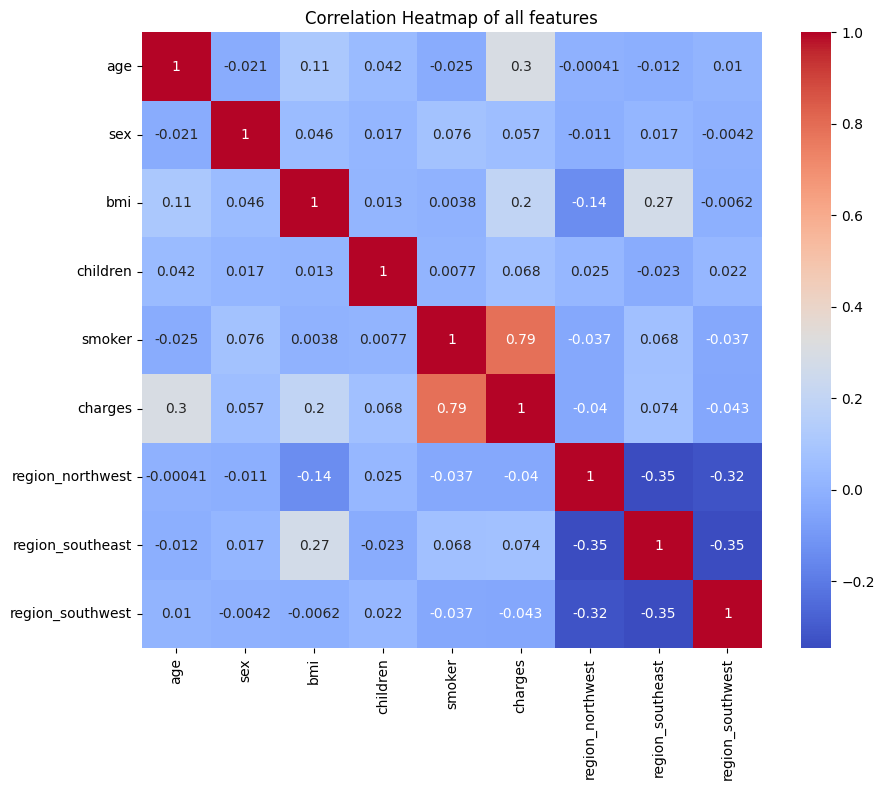

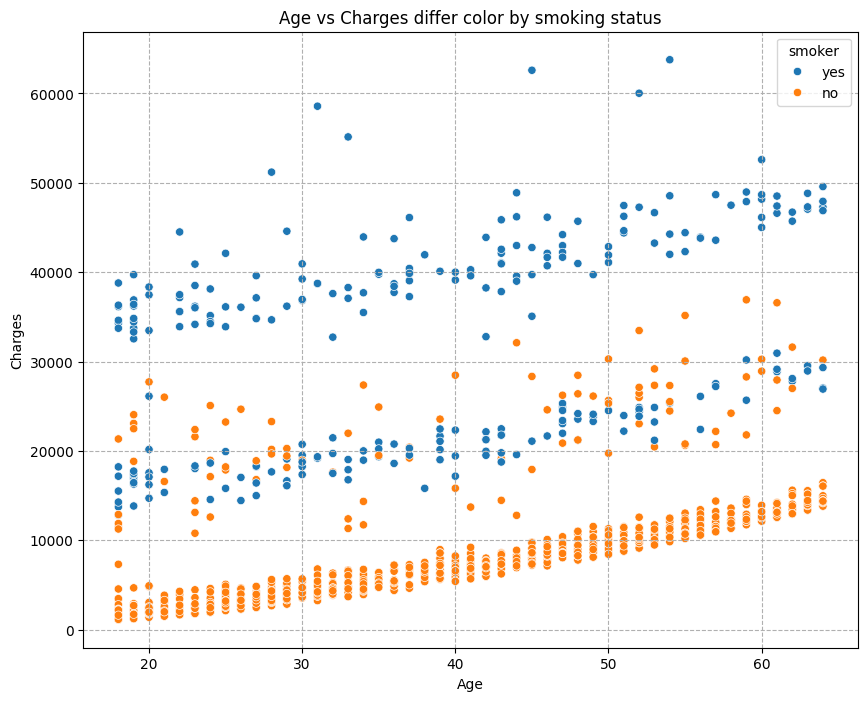

In [5]:
# TODO: Perform EDA

# descriptive statistics
print("Descriptive statistics : \n")
print(reg_df.info())
display(reg_df.describe().T)

# Plot correlation heatmap
corr_df = reg_df.copy()

# apply label encoding for binary categorical columns
cat_cols = ['sex', 'smoker']
le = LabelEncoder()
for col in cat_cols:
    corr_df[col] = le.fit_transform(corr_df[col])

# apply onehot encoding for nominal category region
corr_df = pd.get_dummies(corr_df, columns=['region'], dtype=int, drop_first=True, prefix='region')
display(corr_df.head(5))
print()
corr_mat = corr_df.corr()
# print(corr_mat)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of all features')
plt.show()

print()
# Plot at least one feature vs target
plt.figure(figsize=(10,8))
sns.scatterplot(data=reg_df, x='age', y='charges', hue='smoker')
plt.title('Age vs Charges differ color by smoking status')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.grid(True, linestyle='--')
plt.show()

In the correlation heatmap we see age and bmi has positive correlation with charges. On the other hand smoker status shows the strongest positive correlation over age and bmi, means it is the strongest predictor in this dataset.

The scatter plot shows the blue marked points for smokers tend to have significantly higher charges compared to non smokers across all age group.

## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [4]:
# TODO: Prepare features
X = corr_df.drop(columns=[target_var])
y = corr_df[target_var]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total train data: ", X_train.shape[0])
print("Total test data: ", X_test.shape[0])

Total train data:  1070
Total test data:  268


Here the dataset is splitted into 80/20 ratio for train and test. The standardscaler is applied to remove feature dominance due to high numeric values like age, bmi etc.

## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [6]:
# TODO: Multiple Linear Regression

# Train model

mult_lr = LinearRegression()
mult_lr.fit(X_train_scaled, y_train)
y_pred = mult_lr.predict(X_test_scaled)

# Evaluate using RMSE, MAE, R²

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Metrics for linear regression : \n")
print("Mean Squared Error (MSE): ", mse)
print("Root Mean Squared Error (RMSE): ", rmse)
print("Mean Absolute Error (MAE): ", mae)
print("R-squared (R²): ", r2)

Metrics for linear regression : 

Mean Squared Error (MSE):  33596915.851361476
Root Mean Squared Error (RMSE):  5796.284659276274
Mean Absolute Error (MAE):  4181.1944737536505
R-squared (R²):  0.7835929767120722


Here we can see the R squared value is approximately 78.3%, means the model can identify 78% patterns from this dataset and we know the value closer to 1 defines the model is good. On a typical guess the model prediction gets an average error about 4181 units which is the MAE. The RMSE 5796 is noticeably higher than the MAE, it means when the model makes a mistake it misses by a much large amount.

## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [7]:
# TODO: Polynomial Regression
poly_reg = Pipeline([
 ('Poly', PolynomialFeatures(degree=2, include_bias=False)),
 ('line_reg', LinearRegression())
])

poly_reg.fit(X_train_scaled, y_train)
y_pred = poly_reg.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Metrics for polynomial regression : \n")
print("Mean Squared Error (MSE): ", mse)
print("Root Mean Squared Error (RMSE): ", rmse)
print("Mean Absolute Error (MAE): ", mae)
print("R-squared (R²): ", r2)


Metrics for polynomial regression : 

Mean Squared Error (MSE):  20712805.987918373
Root Mean Squared Error (RMSE):  4551.132385233193
Mean Absolute Error (MAE):  2729.5001336394516
R-squared (R²):  0.866583090316484


With a degree of 2 the polynomial regression model showed a major upgrade over the linear model. The polynomial model can identify patterns approximately 87% from the dataset but previous R squared value for the linear model was 78%. The average prediction error MAE value also shrank down, it dropped from 4181 to 2729. The RMSE also improved as it decressed by using the polynomial regressor. Overall, by analysing the metrics we can say the model is now fitting curved patterns instead of just a straight line and gives much more reliable predictions.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [8]:
# TODO: Support Vector Regression

svr_reg = SVR(kernel='rbf', C=1000.0, epsilon=0.1, gamma='scale')
svr_reg.fit(X_train_scaled, y_train)
y_pred = svr_reg.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Metrics for support vector regression : \n")
print("Mean Squared Error (MSE): ", mse)
print("Root Mean Squared Error (RMSE): ", rmse)
print("Mean Absolute Error (MAE): ", mae)
print("R-squared (R²): ", r2)

Metrics for support vector regression : 

Mean Squared Error (MSE):  39295399.969718136
Root Mean Squared Error (RMSE):  6268.604307955491
Mean Absolute Error (MAE):  2800.214622541228
R-squared (R²):  0.7468874650882389


Here the 'rbf' karnel is used because it helps the model understand complex, curvy relationships without us having to do math amnually to decide what to do. We can see the R squared value 74.7% is a bit lower than our previous models. For the high C value we get lower MAE 2800 but there might be a chance of overfitting because C value tells the model to try hard to fit the training data correctly even if it means making the boundary more complex. However the RMSE 6268 is quite high, means when the model makes a mistake in prediction it misses the real prise by a large amount. Overall we can say the SVR needs careful hyperparameter tuning.

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


Metrics for random forest regression : 

Mean Squared Error (MSE):  20635191.09429901
Root Mean Squared Error (RMSE):  4542.59739513629
Mean Absolute Error (MAE):  2529.522977020684
R-squared (R²):  0.8670830293038984



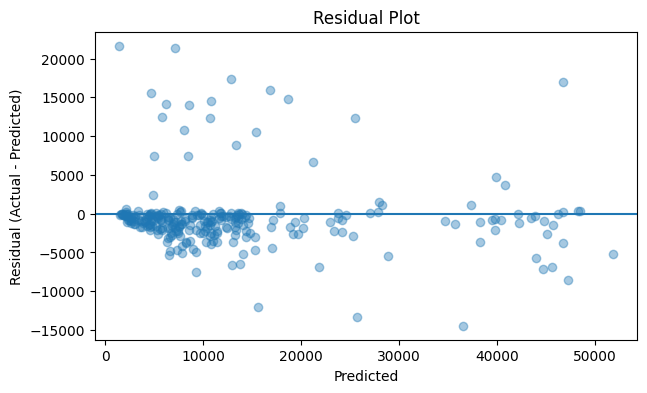

In [9]:
# TODO: Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=80, n_jobs=-1, random_state=42)
rf_reg.fit(X_train_scaled, y_train)
y_pred = rf_reg.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Metrics for random forest regression : \n")
print("Mean Squared Error (MSE): ", mse)
print("Root Mean Squared Error (RMSE): ", rmse)
print("Mean Absolute Error (MAE): ", mae)
print("R-squared (R²): ", r2)

print()
residuals = y_test - y_pred
plt.figure(figsize=(7,4))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()


If we want to evaluate by the metrics then we can see the R squared value 86.7% is the highest amoung the previous models, means the randomforest regressor can learn much better than the rest of the models, also the most lowest MAE 2529 is observed for randomforest regressor. So there is no debate to accept that randomforest is the most accurate model accross all. On the other hand if we see the residual plot visual then we can see the most of the predictions are clustered around 0 line, means this is the final best model we can rely on but it still struggles a little bit with the extreamly high cost bills.

# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [10]:
# TODO: Load classification dataset

cl_df = pd.read_csv('/content/loan_data.csv')

display(cl_df.head(10))

# display(cl_df.describe().T)

print(cl_df.isna().sum())
print("Shape of the dataset : ", cl_df.shape)
target_var = cl_df.columns[-1]
print("Target variable : ", target_var )

class_distribution =  cl_df['loan_status'].value_counts()
print("\nClass distribution : \n", class_distribution)
print("\nRatio of Rejected / Approved= ", class_distribution[0]/class_distribution[1])

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
Shape of the dataset :  (45000, 14)
Target variable :  loan_status

Class distribution : 
 loan_status
0    35000
1    10000
Name: count, dtype: int64

Ratio of Rejected / Approved=  3.5


In this dataset we have total 45000 rows and 14 columns. The dataset is imbalanced if we see the predictive class loan_status distribution with a rejected / approved ratio of 3.5 / 1. The dataset is clean and no null value exists.

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


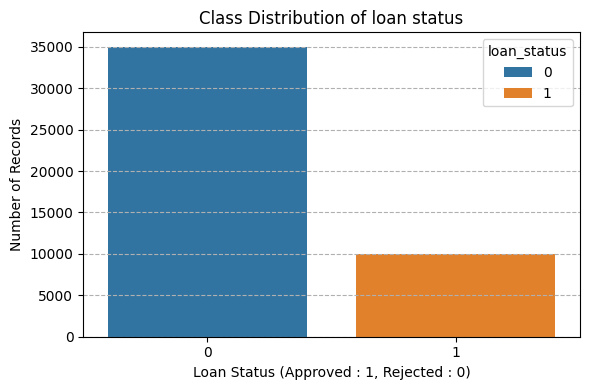

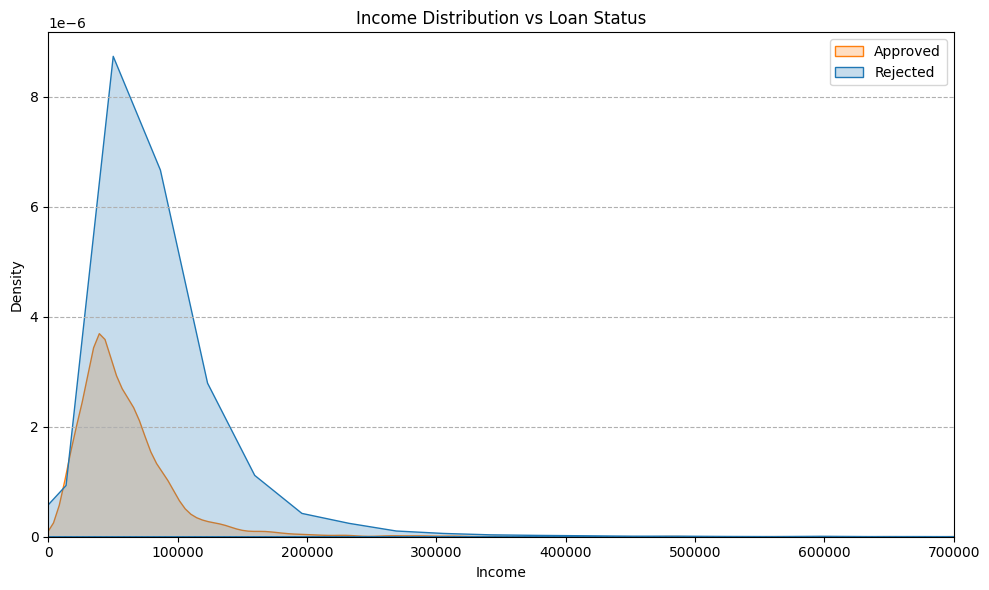

In [11]:
# TODO: Classification EDA
plt.figure(figsize=(6,4))
sns.countplot(data=cl_df, x='loan_status', hue='loan_status')
plt.title('Class Distribution of loan status')
plt.xlabel('Loan Status (Approved : 1, Rejected : 0)')
plt.ylabel('Number of Records')
plt.grid(axis='y',linestyle='--')
plt.tight_layout()
plt.show()

print()

# Plot income	 vs loan status
plt.figure(figsize=(10,6))
sns.kdeplot(data=cl_df, x='person_income', hue='loan_status', fill=True)
plt.title('Income Distribution vs Loan Status')
plt.xlabel('Income')
plt.ylabel('Density')
plt.grid(axis='y',linestyle='--')
plt.legend(['Approved', 'Rejected'])
plt.xlim(0,700000)
plt.tight_layout()
plt.show()



## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [12]:
# TODO: Prepare classification features

# onehot encoding for categorical features
cat_cols = ['person_gender','previous_loan_defaults_on_file', 'person_home_ownership', 'person_education', 'loan_intent']
cl_df = pd.get_dummies(cl_df, columns=cat_cols, dtype=int, drop_first=True)

display(cl_df.head(5))

X = cl_df.drop(columns=[target_var])
y = cl_df[target_var]

# train test spilt with stratification for handling class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,...,person_home_ownership_RENT,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,0,...,1,0,0,0,1,0,0,0,1,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,0,0,1,0,1,0,0,0,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,...,0,0,0,1,0,0,0,1,0,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,0,...,1,1,0,0,0,0,0,1,0,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,1,...,1,0,0,0,1,0,0,1,0,0


## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


Metrics for logistic regression : 

Accuracy (logistic regression) :  0.8997777777777778
Precision (logistic regression) :  0.7895569620253164
Recall (logistic regression) :  0.7485

Confusion Matrix : 
 [[6601  399]
 [ 503 1497]]


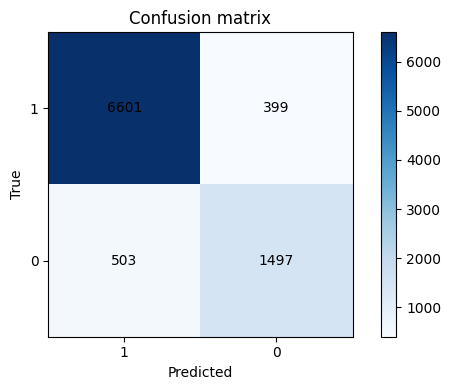

In [16]:
# TODO: Logistic Regression
logi_reg = LogisticRegression(max_iter=100)

logi_reg.fit(X_train_scaled, y_train)

y_pred = logi_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Metrics for logistic regression : \n")
print("Accuracy (logistic regression) : ", accuracy)
print("Precision (logistic regression) : ", precision)
print("Recall (logistic regression) : ", recall)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix : \n", cm)
# confusion matrix visual
plt.figure(figsize=(6, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix")
plt.colorbar()
tick_labels = cl_df[target_var].unique()
plt.xticks([0, 1], tick_labels)
plt.yticks([0, 1], tick_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [20]:
# TODO: SVM Classification
svm_rbf = SVC(kernel='rbf', C=100.0, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)
y_pred = svm_rbf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("Accuracy (SVM with rbf kernel) : ", acc)

cls_report = classification_report(y_test, y_pred)
print(cls_report)

svm_linear = SVC(kernel='linear', C=100.0)
svm_linear.fit(X_train_scaled, y_train)
y_pred = svm_linear.predict(X_test_scaled)

lin_acc = accuracy_score(y_test, y_pred)
print("\nAccuracy (SVM with linear kernel) : ", lin_acc)

lin_cls_report = classification_report(y_test, y_pred)
print(lin_cls_report)

Accuracy (SVM with rbf kernel) :  0.9082222222222223
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7000
           1       0.82      0.75      0.78      2000

    accuracy                           0.91      9000
   macro avg       0.88      0.85      0.86      9000
weighted avg       0.91      0.91      0.91      9000


Accuracy (SVM with linear kernel) :  0.9005555555555556
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [19]:
# TODO: Naive Bayes
# since this is a numerical dataset and a classification problem, gaussian variant will be most suitable
nb_gauss = GaussianNB()
nb_gauss.fit(X_train_scaled, y_train)
y_pred = nb_gauss.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("Accuracy (Naive Bayes with gaussian variant) : ", acc)

Accuracy (Naive Bayes with gaussian variant) :  0.753


## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


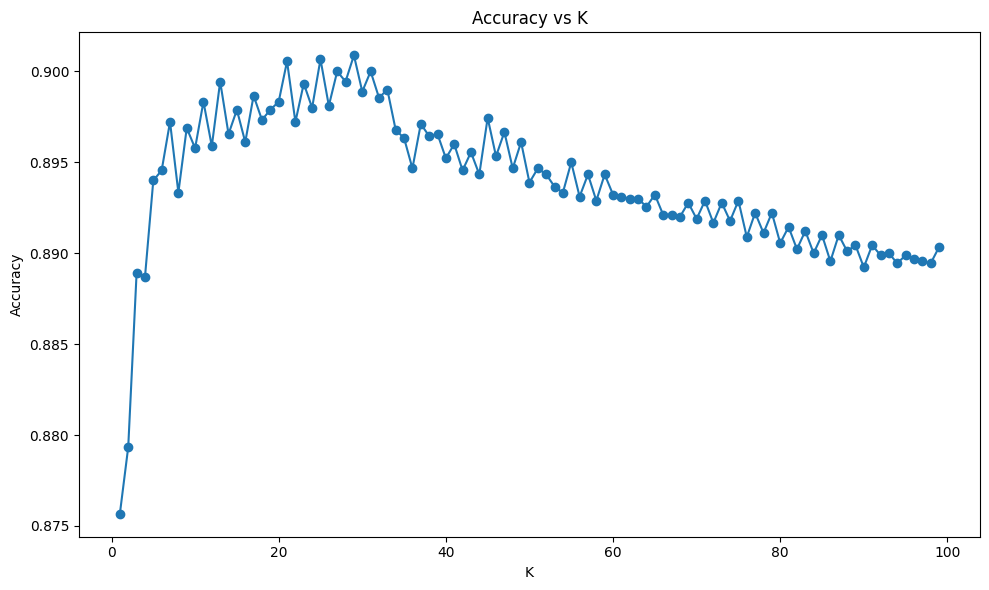

In [21]:
# TODO: KNN
k_vals = range(1, 100)
acc_lst=[]
for k in k_vals:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)
  y_pred = knn.predict(X_test_scaled)
  acc = accuracy_score(y_test, y_pred)
  acc_lst.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(k_vals, acc_lst, marker='o')
plt.title('Accuracy vs K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


In [22]:
best_k = k_vals[np.argmax(acc_lst)]
print("\nBest k value : ", best_k)
print("Best accuracy : ", max(acc_lst))


Best k value :  29
Best accuracy :  0.9008888888888889


## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [23]:
# TODO: Random Forest Classifier
params ={
    "n_estimators": [50,100,150,170,200],
    "max_depth": [None, 2, 8, 10, 20],
    "min_samples_split": [2,3,5,7],
    "max_features": ["sqrt", "log2"]
}

grd_src_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

grd_src_rf.fit(X_train_scaled, y_train)
print("Best parameters : ", grd_src_rf.best_params_)

Best parameters :  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 170}


Accuracy (Random Forest) :  0.9296666666666666


Feature importance chart : 
 previous_loan_defaults_on_file_Yes    0.220389
loan_percent_income                   0.159696
loan_int_rate                         0.156299
person_income                         0.126284
loan_amnt                             0.061933
person_home_ownership_RENT            0.057264
credit_score                          0.054705
person_age                            0.031806
person_emp_exp                        0.028453
cb_person_cred_hist_length            0.026442
loan_intent_HOMEIMPROVEMENT           0.009656
person_home_ownership_OWN             0.009395
person_gender_male                    0.008190
loan_intent_VENTURE                   0.008050
loan_intent_EDUCATION                 0.007611
loan_intent_MEDICAL                   0.007397
person_education_Bachelor             0.006678
loan_intent_PERSONAL                  0.006353
person_education_High School          0.006057
person_education_Master      

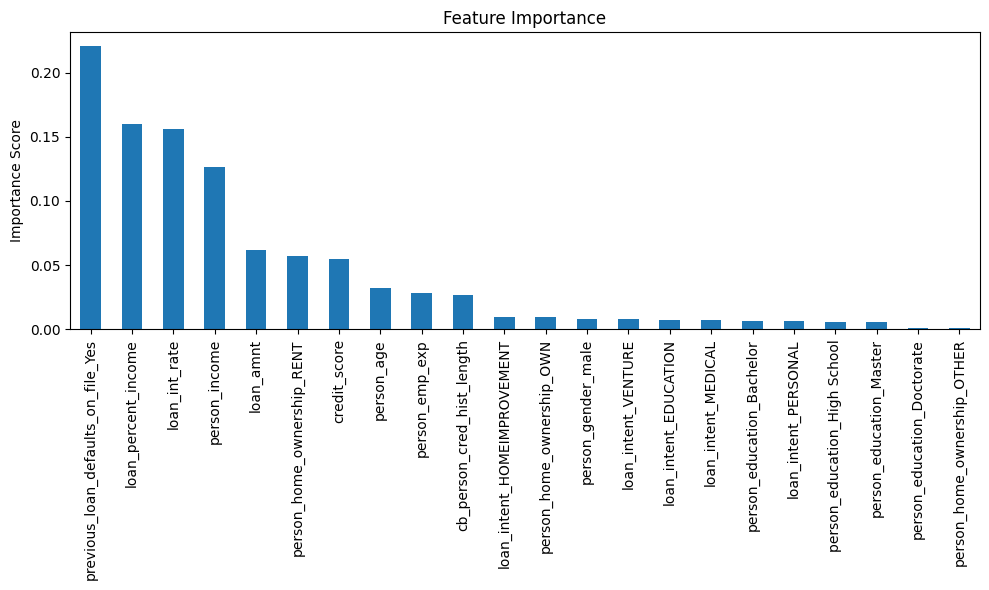

In [28]:
best_rf = grd_src_rf.best_estimator_
y_pred = best_rf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("Accuracy (Random Forest) : ", acc)
print()

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature importance chart : \n", feature_importance)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title('Feature Importance')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


-  The RandomForest Regressor was the best performing model for the insurance dataset. It achieved the highest R squared score approximately 0.867 and lowest MAE approx 2529 among the other regression models. It effectively captured the nonlinear relationship between the features without requiring manual polynomial feature engineering.

-  The RandomForest Classifier performed best for the loan approval task by achieving an accuracy of approximate 92.9% after hyperparameter tuning via GridSearchCV. Due to its ensambled structure it got a better generalization view.

-  In real-world both of these regression and classification model can help to automate the insurance amount issue process, can be used as automated risk assesment tool to flag loan application approval without any manual human investigation.



## TODO: Write your reflection here
The concepts, intutions and the algorithms are so perfectly explained in the module that I can feel confident in ML now. But sometimes I forget some implementations and codes, I don't know how can I overcome this issue but most of the theoritical concepts are clear by my side.